# 17. Palmer Penguenleri Görsel Veri Analizi

**Kategori:** Veri Görselleştirme  
**Gerçek veri seti:** Palmer Penguins  
**Veri kaynağı:** [https://allisonhorst.github.io/palmerpenguins/](https://allisonhorst.github.io/palmerpenguins/)  
**Amaç:** Tür, ada, cinsiyet ve vücut ölçüleri arasındaki ilişkileri görsel olarak analiz etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri kalitesi

In [2]:
df = pd.read_csv(DATA_DIR / "penguins.csv")
display(df.head())
print("Boyut:", df.shape, "| Tekrar:", df.duplicated().sum())
display(pd.DataFrame({"tip": df.dtypes, "eksik": df.isna().sum(), "benzersiz": df.nunique()}))

Boyut: (344, 8) | Tekrar: 0


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


,tip,eksik,benzersiz
species,object,0,3
island,object,0,3
bill_length_mm,float64,2,164
bill_depth_mm,float64,2,80
flipper_length_mm,float64,2,55
body_mass_g,float64,2,94
sex,object,11,2
year,int64,0,3


## 2. Tek değişkenli ve kategorik görseller

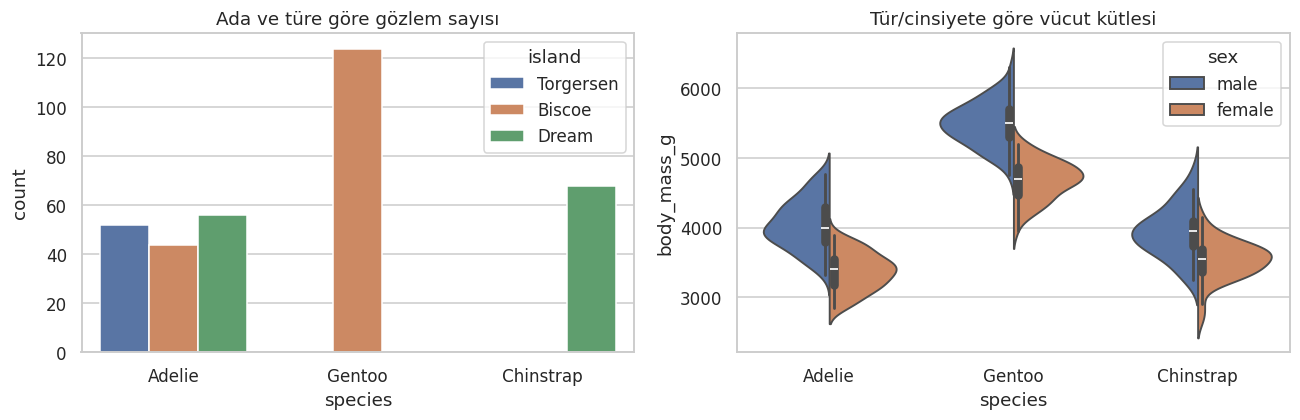

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="species", hue="island", ax=axes[0])
axes[0].set(title="Ada ve türe göre gözlem sayısı")
sns.violinplot(data=df, x="species", y="body_mass_g", hue="sex", split=True, ax=axes[1])
axes[1].set(title="Tür/cinsiyete göre vücut kütlesi")
plt.tight_layout(); plt.show()

## 3. İki değişkenli ilişkiler ve korelasyon

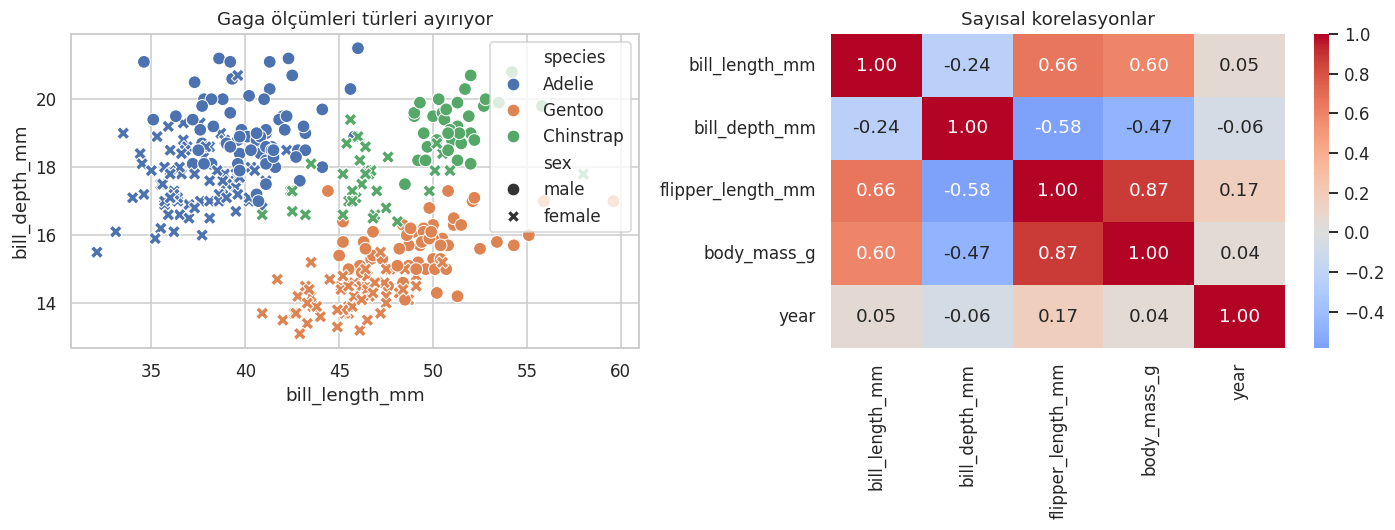

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species",
                style="sex", s=70, ax=axes[0])
axes[0].set(title="Gaga ölçümleri türleri ayırıyor")
numeric = df.select_dtypes(include="number")
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set(title="Sayısal korelasyonlar")
plt.tight_layout(); plt.show()

In [5]:
summary = df.groupby(["species", "sex"])[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
].agg(["count", "mean", "median"]).round(1)
display(summary)
summary.to_csv(RESULT_DIR / "17_penguen_grup_ozeti.csv")
json.dump({"rows": int(len(df)), "missing_cells": int(df.isna().sum().sum()),
           "species": int(df.species.nunique())},
          open(RESULT_DIR / "17_penguen_eda.json", "w"), indent=2)

bill_length_mm               ... body_mass_g                
                          count  mean median  ...       count    mean  median
species   sex                                 ...                            
Adelie    female             73  37.3   37.0  ...          73  3368.8  3400.0
          male               73  40.4   40.6  ...          73  4043.5  4000.0
Chinstrap female             34  46.6   46.3  ...          34  3527.2  3550.0
          male               34  51.1   51.0  ...          34  3939.0  3950.0
Gentoo    female             58  45.6   45.5  ...          58  4679.7  4700.0
          male               61  49.5   49.5  ...          61  5484.8  5500.0

[6 rows x 12 columns]

## Bulgular

- Adelie penguenlerinin gaga uzunluğu diğer iki türe göre genellikle daha düşüktür.
- Gentoo penguenleri daha uzun yüzgeç ve daha yüksek vücut kütlesiyle ayrışır.
- Cinsiyet ve tür birlikte değerlendirilmeden yalnızca kütle üzerinden genelleme yapmak yanıltıcıdır.

Bu notebookta model eğitilmedi; amaç, gerçek veriden görsel ve sayısal bulgu üretmektir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **bir veri setini temel grafiklerle keşfetme** biçimindedir.
Bu notebookta **eksik değer tablosu, kategorik/tek değişkenli/iki değişkenli grafikler ve grup bazlı bulgular** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).